## Zero-Order Model - Baseline Model - Predicts Mean CGM Value

In [3]:
!python -m ensurepip --upgrade
!pip install -r ../requirements.txt

Looking in links: c:\Users\mohamesb\AppData\Local\Temp\tmp9z5kbk3s


Using subject id: 540
Total samples: 14842, train: 11873, test: 2969, n_predictions: 6
Zero-order hold baseline evaluation on test data (flattened across horizon):
  Samples (windows): 2963
  Horizon steps: 6
  MSE: 387.168
  MAE: 13.182


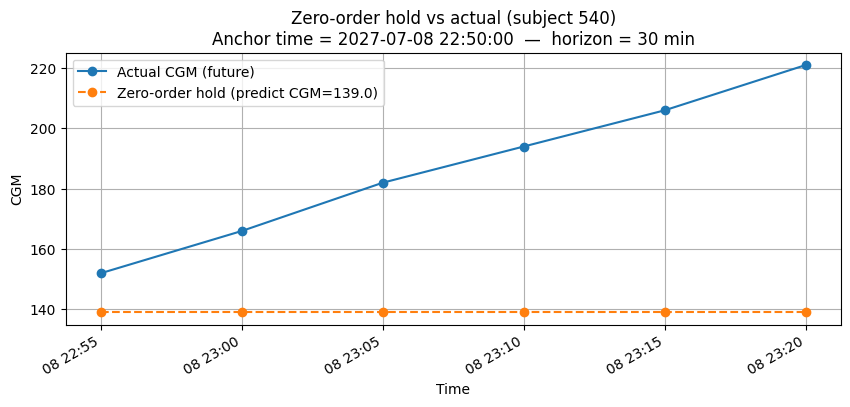

,anchor_time,last_cgm,actual_future_first,predicted_const
0,2027-07-03 18:00:00,238.0,240.0,238.0
1,2027-07-03 18:05:00,240.0,242.0,240.0
2,2027-07-03 18:10:00,242.0,243.0,242.0
3,2027-07-03 18:15:00,243.0,243.0,243.0
4,2027-07-03 18:20:00,243.0,244.0,243.0


In [ ]:
# Zero-order hold (persistence) baseline for CGM
# Paste into a Jupyter notebook cell and run

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -------- configuration --------
DATA_PATH = "../data/OhioT1DM.csv"
PRED_HORIZ_MIN = 30        # prediction horizon in minutes (e.g., 30-min)
STEP_MIN = 5               # sampling interval in minutes (assumed)
TEST_FRACTION = 0.2        # time-based test split fraction
SUBJECT_TO_PLOT = None     # None -> will pick first subject automatically
RNG = 42
# -------------------------------

# load and clean
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# drop rows without CGM (can't use those for persistence)
df = df.dropna(subset=['CGM']).reset_index(drop=True)

# choose a subject (id)
subject_ids = df['id'].unique()
if SUBJECT_TO_PLOT is None:
    subject_id = subject_ids[0]
else:
    subject_id = SUBJECT_TO_PLOT
print("Using subject id:", subject_id)

sub = df[df['id'] == subject_id].copy().reset_index(drop=True)

# prediction horizon in number of samples
n_predictions = PRED_HORIZ_MIN // STEP_MIN

# time-based train/test split (use earliest 80% as train, last 20% as test)
n_total = len(sub)
split_idx = int((1 - TEST_FRACTION) * n_total)

train_df = sub.iloc[:split_idx].reset_index(drop=True)
test_df = sub.iloc[split_idx:].reset_index(drop=True)

print(f"Total samples: {n_total}, train: {len(train_df)}, test: {len(test_df)}, n_predictions: {n_predictions}")

# Build test samples for evaluation:
# For each valid anchor index i (in the test_df), we will use CGM at time i as the prediction for next n_predictions samples.
# We must ensure there are n_predictions future rows available after i within the test_df.
X_last = []      # scalar last CGM at anchor time i
Y_future = []    # vector of length n_predictions (actual future values)
times_future = []  # times corresponding to the future values (for optional plotting alignment)

# We'll iterate over indices of the test_df
for i in range(len(test_df) - n_predictions):
    last_cgm = test_df.loc[i, 'CGM']
    future_slice = test_df.loc[i + 1: i + n_predictions, 'CGM'].values
    future_times = test_df.loc[i + 1: i + n_predictions, 'date'].values
    # sanity check length
    if len(future_slice) == n_predictions:
        X_last.append(last_cgm)
        Y_future.append(future_slice)
        times_future.append(future_times)

X_last = np.array(X_last)                     # shape (N_samples,)
Y_future = np.array(Y_future)                 # shape (N_samples, n_predictions)
times_future = np.array(times_future)         # shape (N_samples, n_predictions) dtype datetime64

# Zero-order hold prediction: repeat last observed CGM across horizon
Y_pred = np.repeat(X_last[:, None], n_predictions, axis=1)  # shape (N_samples, n_predictions)

# Flatten for overall metrics (compare every predicted future point)
y_true_flat = Y_future.ravel()
y_pred_flat = Y_pred.ravel()

mse = mean_squared_error(y_true_flat, y_pred_flat)
mae = mean_absolute_error(y_true_flat, y_pred_flat)

print(f"Zero-order hold baseline evaluation on test data (flattened across horizon):")
print(f"  Samples (windows): {Y_future.shape[0]}")
print(f"  Horizon steps: {n_predictions}")
print(f"  MSE: {mse:.3f}")
print(f"  MAE: {mae:.3f}")

# --- Single window plot: actual vs zero-order hold prediction for one example anchor ---
example_idx = max(0, len(Y_future)//2)  # pick a middle window example
y_actual = Y_future[example_idx]         # length n_predictions
y_pred_single = Y_pred[example_idx]      # repeated scalar
t_future = pd.to_datetime(times_future[example_idx])  # convert to pandas datetimes

plt.figure(figsize=(10,4))
plt.plot(t_future, y_actual, marker='o', linestyle='-', label='Actual CGM (future)')
plt.plot(t_future, y_pred_single, marker='o', linestyle='--', label=f'Zero-order hold (predict CGM={X_last[example_idx]:.1f})')
plt.xlabel('Time')
plt.ylabel('CGM')
plt.title(f'Zero-order hold vs actual (subject {subject_id})\nAnchor time = {test_df.loc[example_idx, "date"]}  —  horizon = {PRED_HORIZ_MIN} min')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()
plt.show()

# Optionally: show a small table of first 5 examples (anchor_time, last_cgm, actual_future[0], ... )
display_df = []
for j in range(min(5, len(Y_future))):
    anchor_time = test_df.loc[j, 'date']
    display_df.append({
        "anchor_time": anchor_time,
        "last_cgm": X_last[j],
        "actual_future_first": Y_future[j, 0],
        "predicted_const": X_last[j]
    })
display(pd.DataFrame(display_df))
